In [105]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [106]:
df = pd.read_csv('hotel_bookings.csv')

In [107]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Data Cleaning

In [108]:
df['deposit_type'].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [109]:
df['reservation_status'].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [110]:
df['customer_type'].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [111]:
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [112]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [113]:
(df.isnull().sum()/len(df))*100

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

### **Observation**

* The `company` column contains **94.31% missing values**. Most customers booked the hotel directly instead of through a company. Since the majority of the values are missing, this column does not provide much useful information for prediction. Therefore, I dropped the `company` column.

* The `children` column has only **0.003% missing values**, which is very small. I filled these missing values with `0`.

* The `country` column has **0.41% missing values**. Since it is a categorical feature with very few missing values, I filled them using the **mode**.

* The `agent` column has **13.69% missing values**. These missing values indicate that the customer booked the hotel directly without using a travel agent. Therefore, I filled the missing values with `0`.


In [114]:
# Drop company column

df = df.drop(columns=['company'])

# Fill missing values in children with 0

df['children'] = df['children'].fillna(0)

# Fill missing values in country with mode

df['country'] = df['country'].fillna( df['country'].mode()[0])

# Fill missing values in agent with 0

df['agent'] = df['agent'].fillna( 0 )

In [115]:
(df.isnull().sum()/len(df))*100

hotel                             0.0
is_canceled                       0.0
lead_time                         0.0
arrival_date_year                 0.0
arrival_date_month                0.0
arrival_date_week_number          0.0
arrival_date_day_of_month         0.0
stays_in_weekend_nights           0.0
stays_in_week_nights              0.0
adults                            0.0
children                          0.0
babies                            0.0
meal                              0.0
country                           0.0
market_segment                    0.0
distribution_channel              0.0
is_repeated_guest                 0.0
previous_cancellations            0.0
previous_bookings_not_canceled    0.0
reserved_room_type                0.0
assigned_room_type                0.0
booking_changes                   0.0
deposit_type                      0.0
agent                             0.0
days_in_waiting_list              0.0
customer_type                     0.0
adr         

In [116]:
# Check for Duplicate rows

df.duplicated().sum()

np.int64(32020)

In [117]:
df.drop_duplicates( inplace = True )

In [118]:
df.duplicated().sum()

np.int64(0)

# Observation

The dataset contains 32,020 duplicate records. Duplicate rows do not provide additional information and may bias the model by overrepresenting certain observations. Therefore, all duplicate records were removed before proceeding with the analysis.

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87370 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87370 non-null  object 
 1   is_canceled                     87370 non-null  int64  
 2   lead_time                       87370 non-null  int64  
 3   arrival_date_year               87370 non-null  int64  
 4   arrival_date_month              87370 non-null  object 
 5   arrival_date_week_number        87370 non-null  int64  
 6   arrival_date_day_of_month       87370 non-null  int64  
 7   stays_in_weekend_nights         87370 non-null  int64  
 8   stays_in_week_nights            87370 non-null  int64  
 9   adults                          87370 non-null  int64  
 10  children                        87370 non-null  float64
 11  babies                          87370 non-null  int64  
 12  meal                            8737

In [120]:
# Converting the reservation status date column date time data type

df['reservation_status_date'] = pd.to_datetime( df['reservation_status_date'])

In [121]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370.000000,87370
mean,0.274969,79.911686,2016.210290,26.839533,15.815360,1.005448,2.625798,1.875953,0.138675,0.010828,0.039087,0.030422,0.184045,0.271672,81.011194,0.749788,106.346935,0.084251,0.698638,2016-08-31 03:47:43.600778496
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,72.000000,0.000000,0.000000,2016-03-18 00:00:00
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,98.100000,0.000000,0.000000,2016-09-08 00:00:00
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,134.000000,0.000000,1.000000,2017-03-05 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.446501,86.056471,0.686116,13.673204,8.834842,1.031974,2.053692,0.626473,0.455933,0.113613,0.193802,0.369200,1.732148,0.727335,109.941520,10.017213,55.004259,0.281571,0.831946,NaN


In [122]:
(df['adr'] < 0 ).sum()

np.int64(1)

In [123]:
# Zero guests
df[(df['adults'] == 0) &
   (df['children'] == 0) &
   (df['babies'] == 0)].shape

(166, 31)

During data quality checks, I found one record with a negative ADR (Average Daily Rate), which is not a valid room price. Therefore, I removed that record. I also identified 166 bookings with zero adults, zero children, and zero babies. Since a hotel booking cannot exist without any guests, these records were considered invalid and removed from the dataset.

In [124]:
df = df[df['adr'] >= 0]

In [125]:
df = df[~ (
    ( df['adults'] == 0 ) &
    ( df['children'] == 0)&
    ( df['babies'] == 0)

)]


# Exploratory Data Analysis

## Univariate Analysis

In [126]:
round(df['is_canceled'].value_counts(normalize=True) * 100, 2)

is_canceled
0    72.47
1    27.53
Name: proportion, dtype: float64

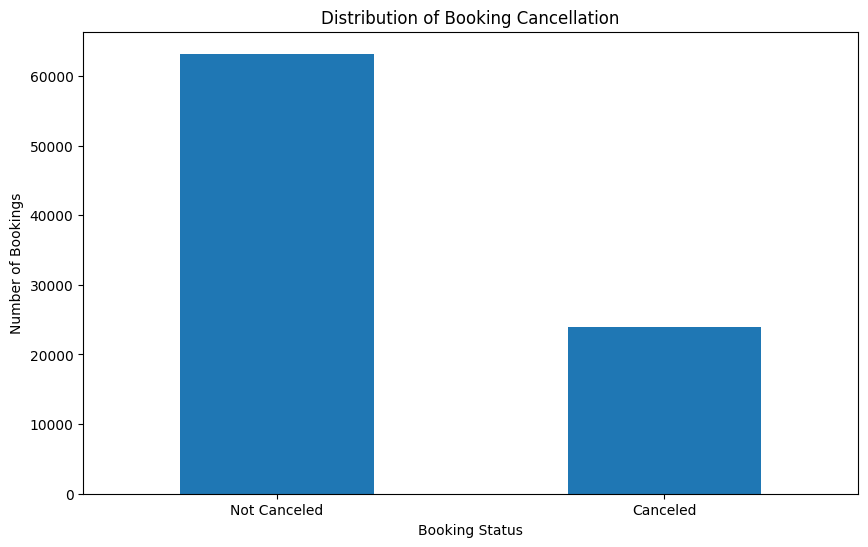

In [127]:
plt.figure(figsize = (10,6))

df['is_canceled'].value_counts().plot(kind = 'bar')

plt.title("Distribution of Booking Cancellation")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.xticks([0, 1], ['Not Canceled', 'Canceled'], rotation=0)

plt.show()

Out of the total bookings, 72% were not canceled and 27% were canceled. This indicates that the dataset contains more completed bookings than canceled bookings, although a significant proportion of cancellations still exists.

In [128]:
df['hotel'].value_counts()

hotel
City Hotel      53272
Resort Hotel    33931
Name: count, dtype: int64

In [129]:
round(df['hotel'].value_counts(normalize = True) * 100 , 2 )

hotel
City Hotel      61.09
Resort Hotel    38.91
Name: proportion, dtype: float64

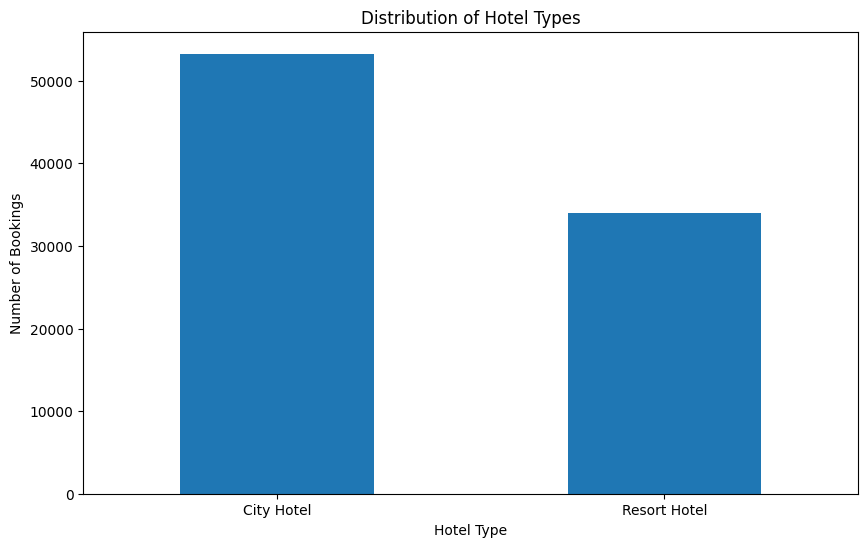

In [130]:
plt.figure(figsize = (10,6))

df['hotel'].value_counts().plot(kind  = 'bar')

plt.title("Distribution of Hotel Types")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.show()

In [131]:
df.select_dtypes( include = 'object').columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status'],
      dtype='object')

In [132]:
df['meal'].value_counts()

meal
BB           67883
SC            9391
HB            9079
Undefined      490
FB             360
Name: count, dtype: int64

In [133]:
round(df['meal'].value_counts(normalize = True) * 100,2)

meal
BB           77.84
SC           10.77
HB           10.41
Undefined     0.56
FB            0.41
Name: proportion, dtype: float64

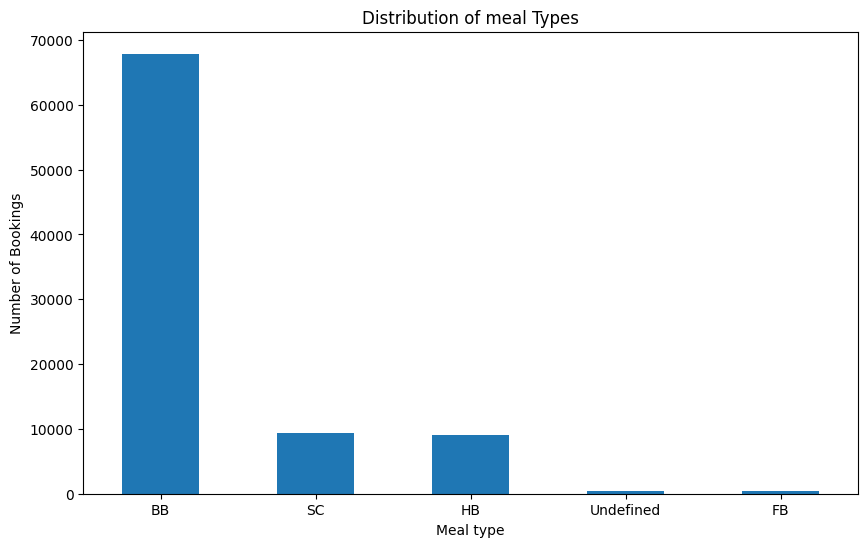

In [134]:
plt.figure(figsize = (10,6))

df['meal'].value_counts().plot(kind = 'bar')

plt.title("Distribution of meal Types")
plt.xlabel("Meal type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.show()

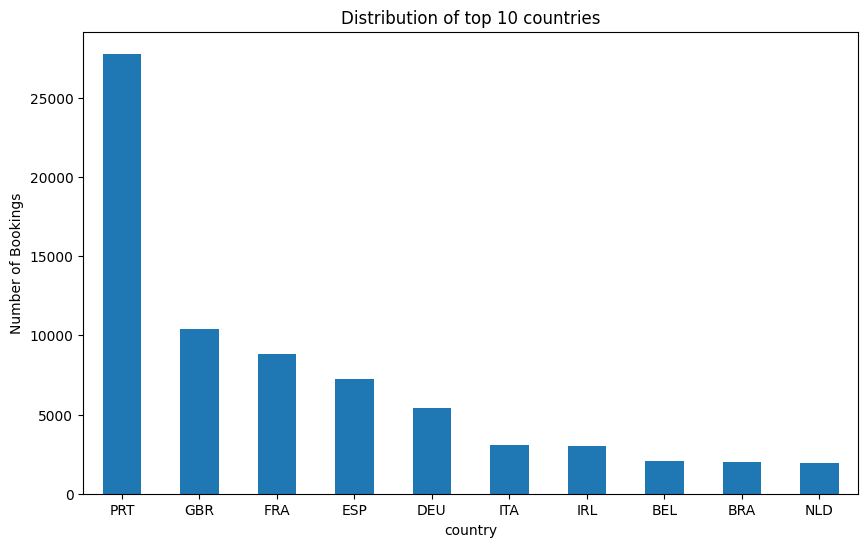

In [135]:
plt.figure(figsize = (10,6))

df['country'].value_counts().head(10).plot(kind = 'bar')

plt.title("Distribution of top 10 countries")
plt.xlabel("country")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.show()

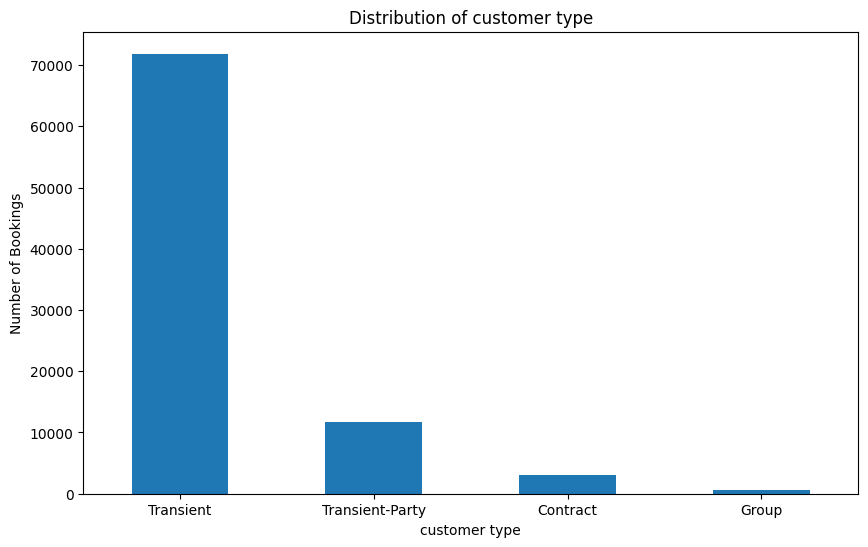

In [136]:

plt.figure(figsize = (10,6))

df['customer_type'].value_counts().plot(kind = 'bar')

plt.title("Distribution of customer type")
plt.xlabel("customer type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.show()

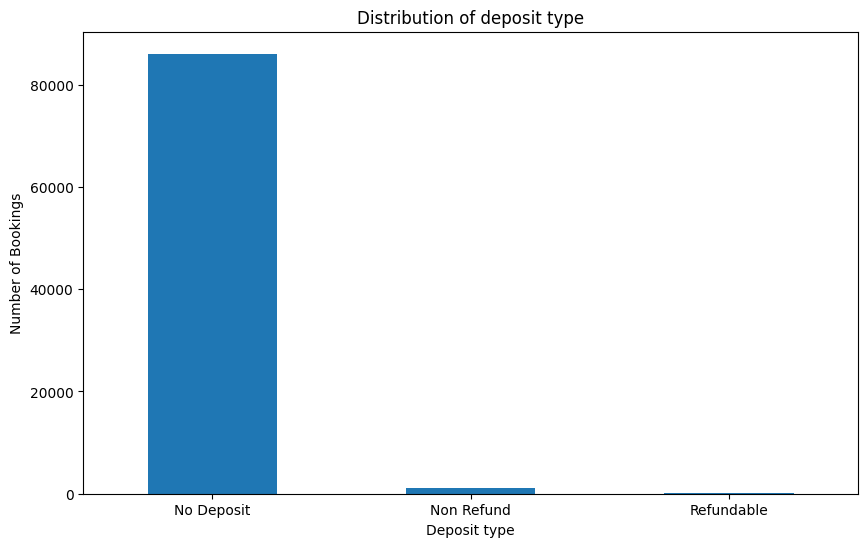

In [137]:
plt.figure(figsize = (10,6))

df['deposit_type'].value_counts().plot(kind = 'bar')

plt.title("Distribution of deposit type")
plt.xlabel("Deposit type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.show()

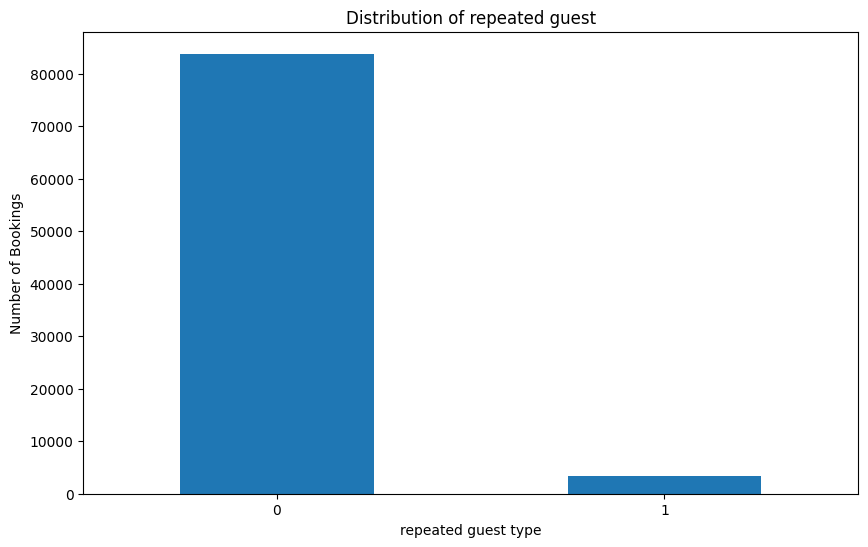

In [138]:
plt.figure(figsize = (10,6))

df['is_repeated_guest'].value_counts().plot(kind = 'bar')

plt.title("Distribution of repeated guest")
plt.xlabel("repeated guest type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.show()

## Bivariate Analysis

### Categorical Feature vs Target

In [139]:
pd.crosstab( df['hotel'], df['is_canceled'])

is_canceled,0,1
hotel,,
City Hotel,37237,16035
Resort Hotel,25958,7973


In [140]:
round(pd.crosstab( df['hotel'], df['is_canceled'], normalize = 'index') * 100,2)

is_canceled,0,1
hotel,,
City Hotel,69.9,30.1
Resort Hotel,76.5,23.5


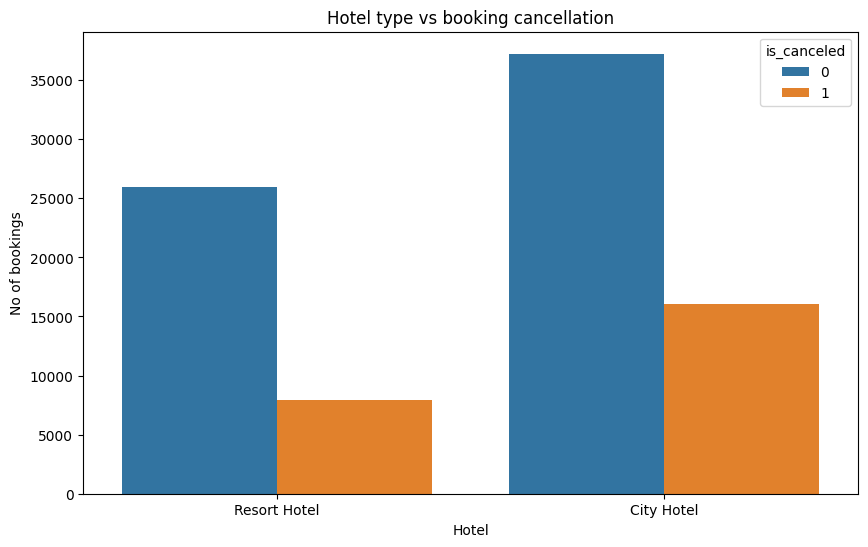

In [141]:
plt.figure(figsize = (10,6))

sns.countplot( data = df, x = 'hotel', hue = 'is_canceled')

plt.title( "Hotel type vs booking cancellation")
plt.xlabel("Hotel")
plt.ylabel("No of bookings")

plt.show()

City Hotels have a higher booking cancellation rate (30.1%) compared to Resort Hotels (23.5%). This indicates that customers booking City Hotels are more likely to cancel their reservations than those booking Resort Hotels. Therefore, the hotel feature may be an important predictor of booking cancellation.

In [142]:
pd.crosstab( df['deposit_type'], df['is_canceled'])

is_canceled,0,1
deposit_type,,
No Deposit,63059,22999
Non Refund,55,983
Refundable,81,26


In [143]:
round(pd.crosstab( df['deposit_type'], df['is_canceled'], normalize = 'index') * 100 ,2 )

is_canceled,0,1
deposit_type,,
No Deposit,73.28,26.72
Non Refund,5.30,94.70
Refundable,75.70,24.30


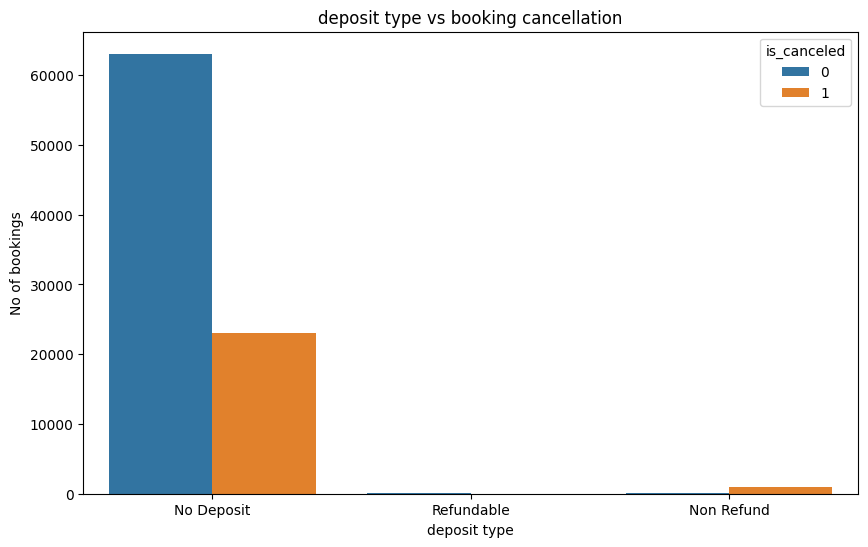

In [144]:
plt.figure(figsize = (10,6))

sns.countplot( data = df, x = 'deposit_type', hue = 'is_canceled')

plt.title( "deposit type vs booking cancellation")
plt.xlabel("deposit type")
plt.ylabel("No of bookings")

plt.show()

In [145]:
df['deposit_type'].value_counts()

deposit_type
No Deposit    86058
Non Refund     1038
Refundable      107
Name: count, dtype: int64

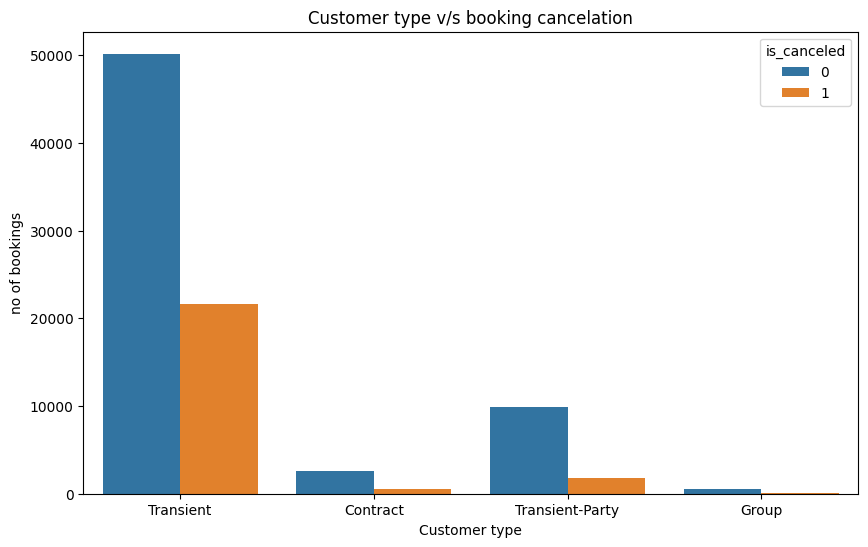

In [146]:
plt.figure(figsize = (10,6))

sns.countplot( data = df, x = 'customer_type',hue = 'is_canceled')

plt.title( 'Customer type v/s booking cancelation')
plt.xlabel('Customer type')
plt.ylabel('no of bookings')
plt.show()

In [147]:
df.select_dtypes( include = ['int64', 'float']).columns

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

In [148]:
df.groupby('is_canceled')['lead_time'].mean()

is_canceled
0     70.207944
1    105.739087
Name: lead_time, dtype: float64

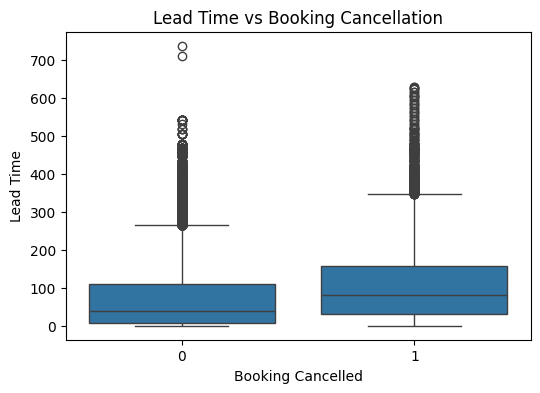

In [149]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x='is_canceled', y='lead_time')

plt.title("Lead Time vs Booking Cancellation")
plt.xlabel("Booking Cancelled")
plt.ylabel("Lead Time")

plt.show()

Customers whose bookings were canceled have a significantly higher average lead time than those whose bookings were not canceled. This suggests that customers who book well in advance are more likely to cancel their reservations. Therefore, lead_time appears to be an important feature for predicting booking cancellations.

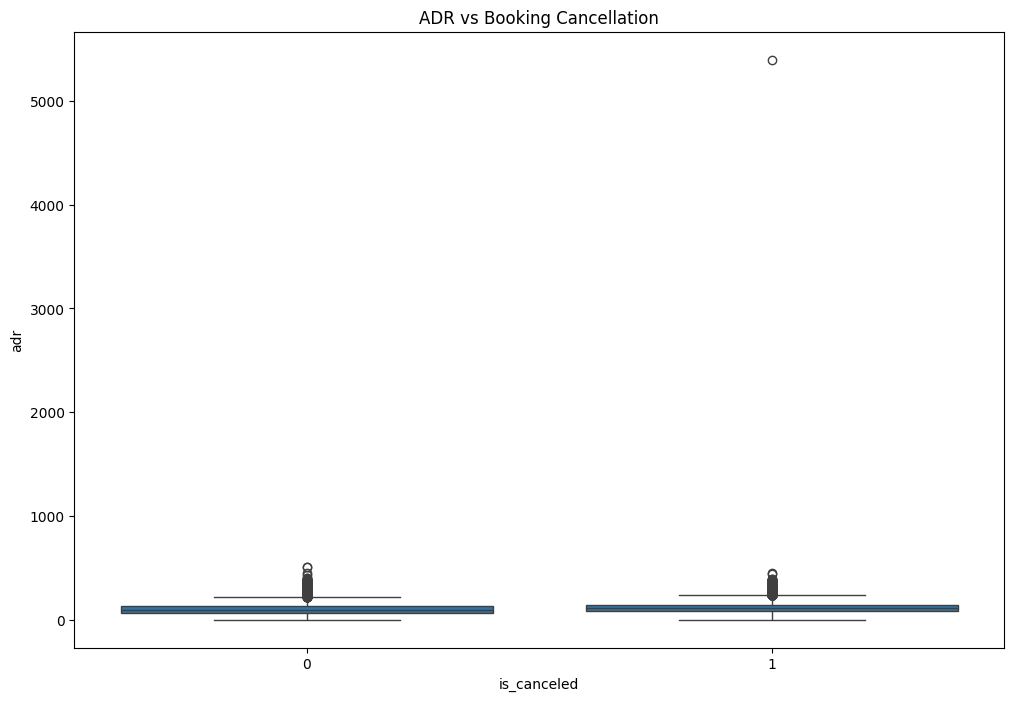

In [150]:
plt.figure(figsize=(12,8))

sns.boxplot(data=df, x='is_canceled', y='adr')

plt.title("ADR vs Booking Cancellation")
plt.show()

In [151]:
df.groupby('is_canceled')['adr'].mean()

is_canceled
0    102.226762
1    117.853871
Name: adr, dtype: float64

In [152]:
df.groupby('is_canceled')['previous_cancellations'].mean()

is_canceled
0    0.018688
1    0.061271
Name: previous_cancellations, dtype: float64

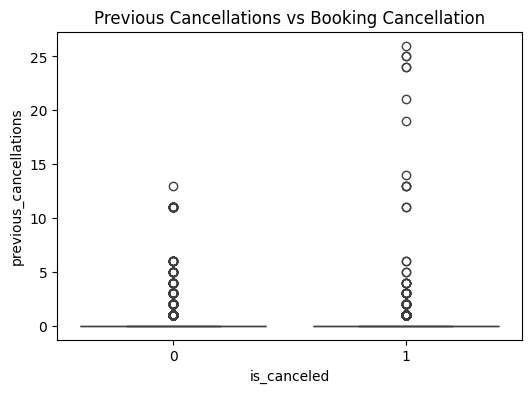

In [153]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x='is_canceled', y='previous_cancellations')

plt.title("Previous Cancellations vs Booking Cancellation")
plt.show()

Customers whose bookings were canceled have a higher average number of previous cancellations compared to customers whose bookings were not canceled. This suggests that customers with a history of canceling bookings are more likely to cancel again, making previous_cancellations a useful feature for predicting booking cancellations.

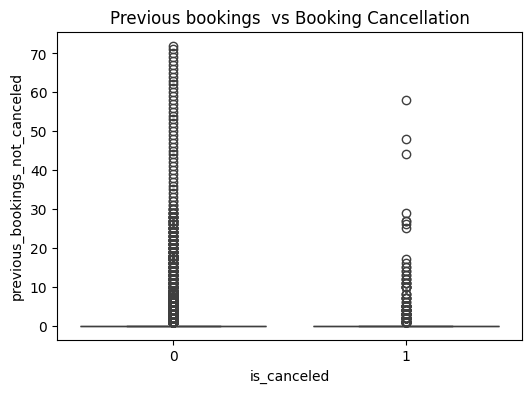

In [154]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df, x='is_canceled', y='previous_bookings_not_canceled')

plt.title("Previous bookings  vs Booking Cancellation")
plt.show()

In [155]:
df.groupby('is_canceled')['previous_bookings_not_canceled'].mean()

is_canceled
0    0.239845
1    0.037321
Name: previous_bookings_not_canceled, dtype: float64

Customers whose bookings were not canceled have a higher average number of previous successful bookings compared to customers whose bookings were canceled. This suggests that customers with a positive booking history are less likely to cancel future reservations. Therefore, previous_bookings_not_canceled appears to be an important feature for predicting booking cancellations.

In [156]:
df.groupby('is_canceled')['booking_changes'].mean()

is_canceled
0    0.309407
1    0.160988
Name: booking_changes, dtype: float64

Customers whose bookings were not canceled made more booking changes on average than customers who canceled. This suggests that customers who invest time in modifying their reservations are more committed to their travel plans and are therefore less likely to cancel.

In [157]:
df.groupby('is_canceled')['required_car_parking_spaces'].mean()

is_canceled
0    0.11637
1    0.00000
Name: required_car_parking_spaces, dtype: float64

Customers whose bookings were not canceled requested more parking spaces on average than customers who canceled. This suggests that customers requesting parking facilities are more committed to their travel plans and are therefore less likely to cancel their reservations. Hence, required_car_parking_spaces may be an important predictor of booking cancellation.

In [158]:
df.groupby('is_canceled')['total_of_special_requests'].mean()

is_canceled
0    0.760994
1    0.535863
Name: total_of_special_requests, dtype: float64

Customers who made more special requests were less likely to cancel their bookings. This suggests that customers who take the time to communicate their preferences and requirements are generally more committed to their travel plans. Therefore, total_of_special_requests appears to be an important feature for predicting booking cancellations.

## Conclusion

During EDA, I identified several features that showed a strong relationship with booking cancellation. Features such as lead time and previous cancellations increased the likelihood of cancellation, whereas previous successful bookings, booking changes, special requests, and parking space requests indicated stronger customer commitment and were associated with lower cancellation rates. These insights suggest that these features are likely to be important predictors in the Random Forest model.

In [159]:
corr = df.select_dtypes( include = [ 'int64', 'float']).corr()

Text(0.5, 1.0, 'Correlation heatmap')

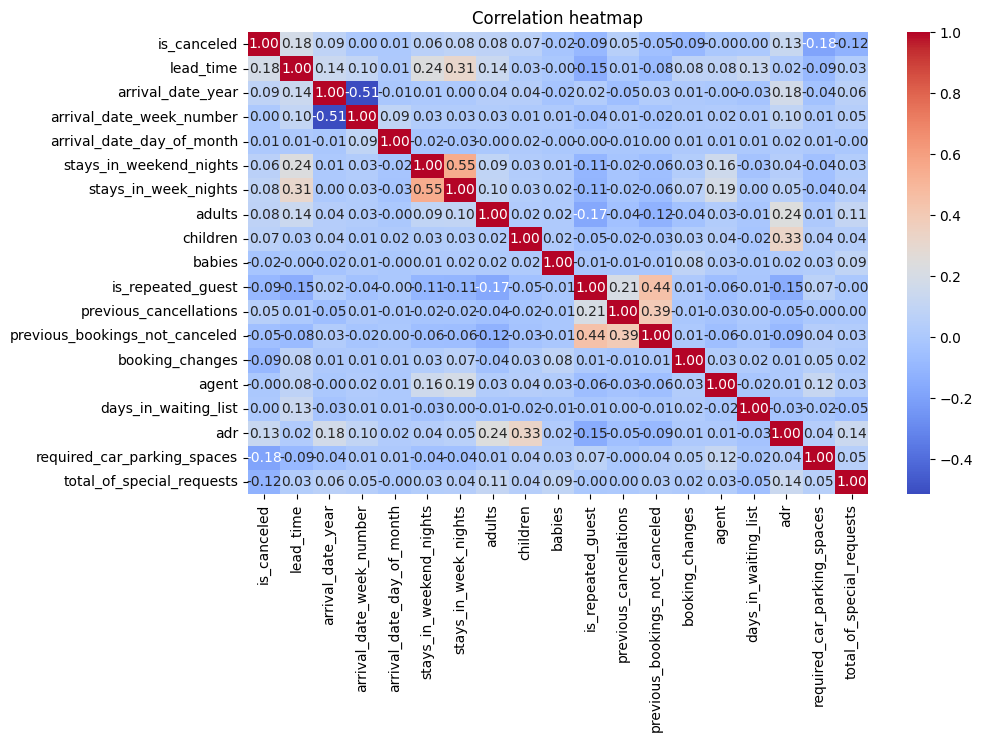

In [160]:
plt.figure(figsize = (10,6))

sns.heatmap( corr, cmap = 'coolwarm', annot = True, fmt = '.2f')

plt.title( "Correlation heatmap")

The correlation heatmap shows that there is no strong multicollinearity among the numerical features, as no pair of features has a correlation coefficient greater than 0.8 (or less than -0.8). This indicates that the numerical features do not have a strong linear relationship with each other and can be retained for model training.

In [161]:
df.select_dtypes(include='object').columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status'],
      dtype='object')

In [162]:
#Drop leakage columns

df.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)

In [163]:
df = pd.get_dummies( df, columns = df.select_dtypes(include='object').columns, drop_first = True, dtype = int)

Since the dataset contained nominal categorical variables such as hotel type, meal type, market segment, and customer type, I used One-Hot Encoding to convert them into numerical features. This avoids introducing an artificial order among categories and allows the Random Forest model to process categorical information effectively

In [164]:
# Separate Features and Target

x = df.drop('is_canceled', axis =1)
y  =df['is_canceled']

In [165]:
# Train-Test Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, stratify = y, random_state = 42)

In [ ]:
# Train Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state  =42)

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


The baseline Random Forest model achieved good predictive performance with an accuracy of approximately 85%. It was able to classify both canceled and non-canceled bookings reasonably well. Since the business objective is to identify as many booking cancellations as possible, recall for the canceled class is considered an important evaluation metric in addition to overall accuracy. Although the baseline model performed well, there is still room for improvement. Therefore, hyperparameter tuning will be performed to improve recall while maintaining high accuracy.

In [ ]:
# Number of Decision Trees used

len(rf.estimators_)

rf.estimators_[0]

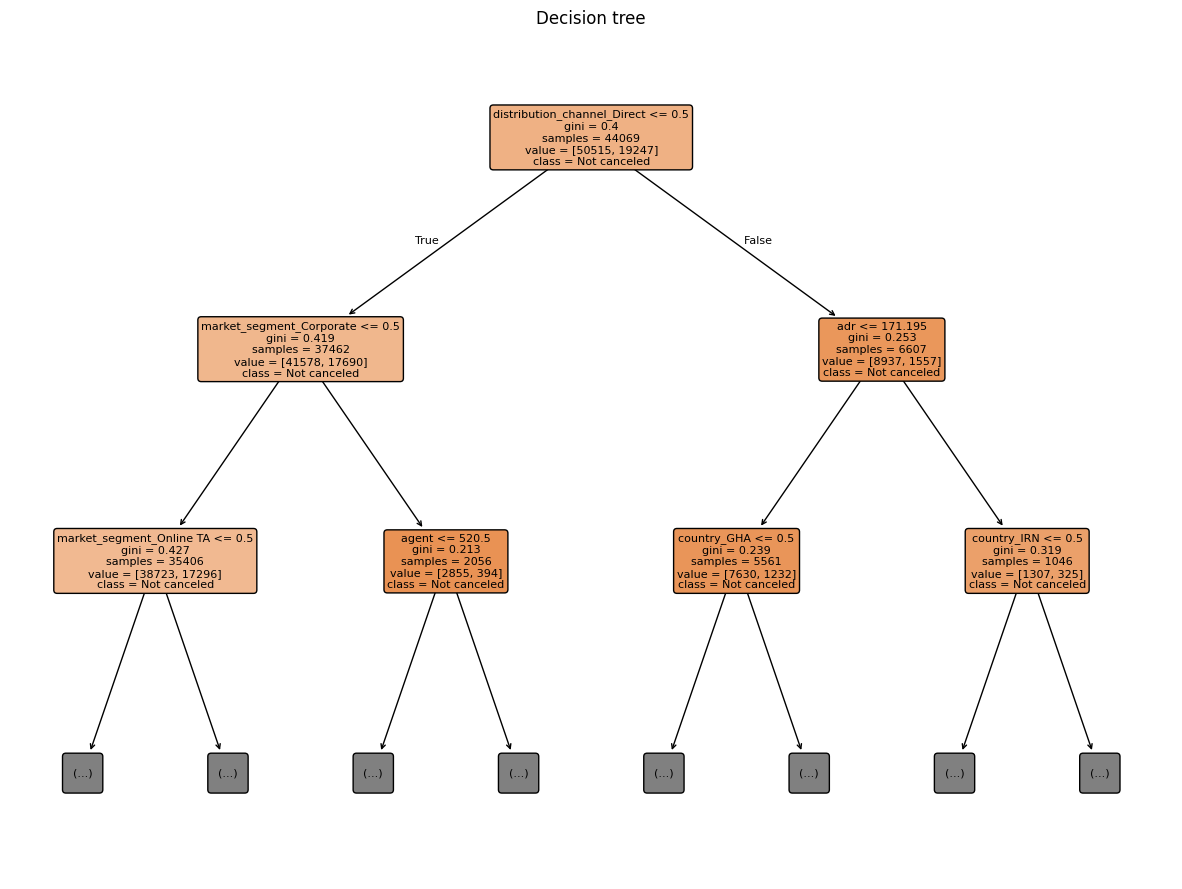

In [195]:
from sklearn import tree
plt.figure(figsize = (15,11))

tree.plot_tree(
    rf.estimators_[0],
    max_depth = 2,
    feature_names = x.columns,
    class_names = ['Not canceled', 'Canceled'],
    filled = True,
    rounded = True,
    fontsize  =8

)
plt.title("Decision tree")
plt.show()

# Hyper parameter tuning

In [95]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [20, 30, None],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 5]
}

In [96]:
from sklearn.model_selection import RandomizedSearchCV

randomsearch = RandomizedSearchCV(
      estimator = rf,
      param_distributions = param_grid,
      n_iter = 3,
      cv = 3,
      scoring = 'recall',
      random_state = 42,
      n_jobs = -1,
      verbose = 2

)

In [97]:
randomsearch.fit(x_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'max_depth': [20, 30, None],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [200, 300, 500]},
                   random_state=42, scoring='recall', verbose=2)

In [98]:
best_rf = randomsearch.best_estimator_

In [99]:
y_pred1  = best_rf.predict(x_test)

In [100]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print("Recall   :", recall_score(y_test, y_pred1))
print("F1 Score :", f1_score(y_test, y_pred1))

Accuracy : 0.8570036121782008
Precision: 0.7909732728189611
Recall   : 0.6532694710537276
F1 Score : 0.7155565693430657


In [171]:
print(rf)

RandomForestClassifier(random_state=42)


In [172]:
len(rf.estimators_)

100

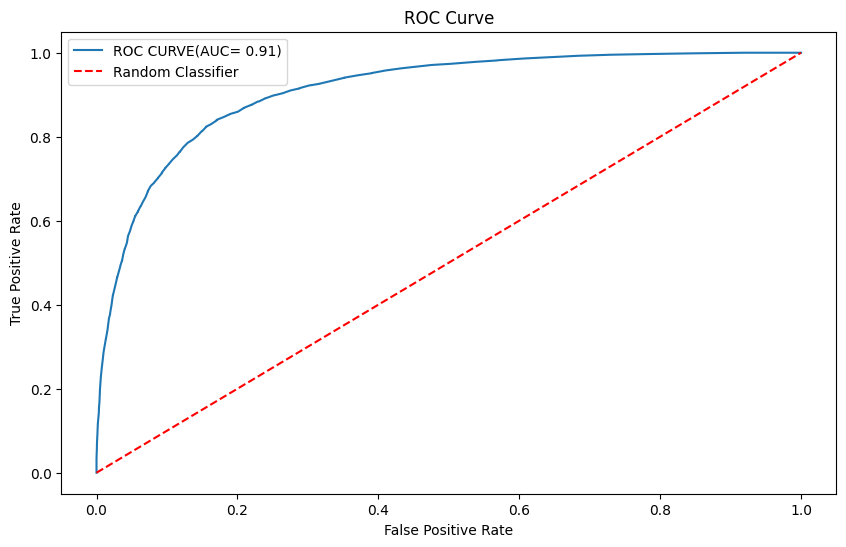

In [177]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of positive class (Canceled = 1)
y_prob = rf.predict_proba(x_test)[:, 1]

# Calculate ROC values
fpr,tpr, thresholds = roc_curve( y_test, y_prob)

# Calculate AUC
auc_score  = roc_auc_score( y_test, y_prob)

# Plot
plt.figure(figsize = (10,6))

plt.plot( fpr, tpr, label  =f'ROC CURVE(AUC= { auc_score:.2f})')
plt.plot( [0,1], [0,1],linestyle='--', color='red', label='Random Classifier')


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

he Random Forest model achieved an ROC-AUC score of 0.91, indicating excellent classification performance. The ROC curve is well above the diagonal reference line, showing that the model effectively distinguishes between canceled and non-canceled bookings across various decision thresholds.

## Final Model Selection and Conclusion

After evaluating the baseline Random Forest model and performing hyperparameter tuning, the **hyperparameter-tuned Random Forest** was selected as the final model for this project.

The tuned model achieved **85.70% accuracy**, **79.10% precision**, **65.33% recall**, an **F1-score of 71.56%**, and an **ROC-AUC score of 0.91**, showing excellent ability to distinguish between canceled and non-canceled bookings.

The primary objective of this project was not only to achieve high accuracy but also to improve **recall**. In the context of hotel booking cancellation prediction, a **False Negative (Type II Error)** occurs when the model predicts that a customer will not cancel, but the customer actually cancels. Missing such bookings may prevent the hotel from taking proactive actions, resulting in **financial losses, inefficient room allocation, and missed opportunities to reduce cancellations**.

Therefore, the final model was selected because it provided an improvement in both **accuracy and recall** compared with the baseline model. Since reducing **Type II errors** was more important for this business problem, priority was given to improving recall while maintaining good overall performance.

This project also highlights an important machine learning principle: **the best model is not always the one with the highest accuracy**. The final model should be selected based on the business objective and the impact of prediction errors rather than accuracy alone.

Overall, the final Random Forest model provides a good balance between predictive performance and business requirements, making it an effective solution for hotel booking cancellation prediction.


## Prediction on unseen data

In [178]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline RF": [0.8545, 0.7882, 0.6449, 0.7094, 0.91],
    "Tuned RF": [0.8570, 0.7910, 0.6533, 0.7156, 0.91]
})

comparison

,Metric,Baseline RF,Tuned RF
0,Accuracy,0.8545,0.8570
1,Precision,0.7882,0.7910
2,Recall,0.6449,0.6533
3,F1-score,0.7094,0.7156
4,ROC-AUC,0.9100,0.9100


In [182]:
# Prediciton on unseen data

new_booking = pd.DataFrame({
    'hotel': ['City Hotel'],
    'lead_time': [120],
    'arrival_date_month': ['August'],
    'stays_in_weekend_nights': [2],
    'stays_in_week_nights': [3],
    'adults': [2],
    'children': [1],
    'babies': [0],
    'meal': ['BB'],
    'market_segment': ['Online TA'],
    'distribution_channel': ['TA/TO'],
    'is_repeated_guest': [0],
    'previous_cancellations': [1],
    'previous_bookings_not_canceled': [0],
    'reserved_room_type': ['A'],
    'assigned_room_type': ['A'],
    'booking_changes': [0],
    'deposit_type': ['No Deposit'],
    'customer_type': ['Transient'],
    'adr': [120.50],
    'required_car_parking_spaces': [0],
    'total_of_special_requests': [1]
})

In [183]:
new_booking = pd.get_dummies(new_booking)

In [184]:
new_booking = new_booking.reindex(columns=x_train.columns, fill_value=0)

In [185]:
prediction = rf.predict(new_booking)

if prediction[0] == 1:
    print("Booking is likely to be Canceled.")
else:
    print("Booking is likely to be Not Canceled.")

Booking is likely to be Not Canceled.


In [189]:
plt.savefig('Correaltion Heatmap', dpi = 300, bbox_inches = 'tight')

<Figure size 640x480 with 0 Axes>

In [194]:
plt.savefig('ROC_Curve',dpi = 300, bbox_inches = 'tight')

<Figure size 640x480 with 0 Axes>

In [196]:
plt.savefig('Decision tree', dpi = 300, bbox_inches = 'tight')

<Figure size 640x480 with 0 Axes>